In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons, make_blobs
from dbscan import DBSCAN

In [2]:
# 1. Generate "Shape Salad" Data
# Combining Moons (Non-linear) and Blobs (Dense) to test robustness
X_moons, _ = make_moons(n_samples=200, noise=0.05, random_state=0)
X_moons[:, 0] -= 0.5 # Shift moons slightly

# Add a dense blob nearby
X_blobs, _ = make_blobs(n_samples=100, centers=[[1.5, 1.5]], cluster_std=0.3, random_state=0)

# Add some random noise outliers
rng = np.random.RandomState(42)
X_noise = rng.uniform(low=-1.5, high=2.5, size=(20, 2))

# Stack them all
X = np.vstack([X_moons, X_blobs, X_noise])

In [3]:
# 2. Run DBSCAN
# We need an eps that connects the moons but doesn't bridge the gap to the blob
db = DBSCAN(eps=0.25, min_samples=5)
y_pred = db.fit_predict(X)

C:\Users\chaud\AppData\Local\Temp\ipykernel_28948\840750321.py:26: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(xy[:, 0], xy[:, 1], s=size, c=[col], marker=marker, edgecolors='k', alpha=alpha, label=label)


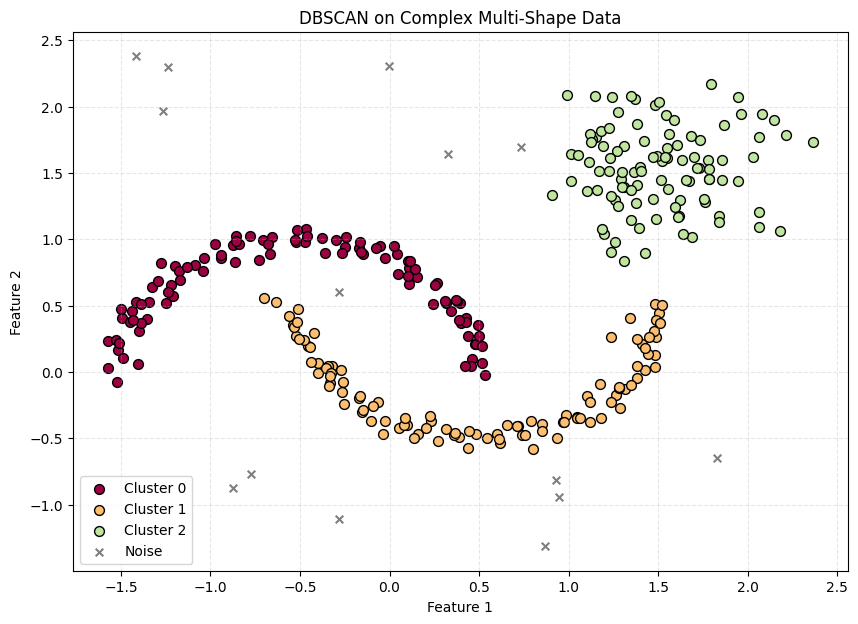

In [4]:
# 3. Plot
plt.figure(figsize=(10, 7))

# Get unique labels
unique_labels = set(y_pred)
# Generate colors
colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels))]

for k, col in zip(unique_labels, colors):
    if k == -1:
        # Black used for noise.
        col = [0, 0, 0, 1]
        label = "Noise"
        marker = 'x'
        size = 30
        alpha = 0.5
    else:
        label = f"Cluster {k}"
        marker = 'o'
        size = 50
        alpha = 1.0

    class_member_mask = (y_pred == k)
    
    xy = X[class_member_mask]
    plt.scatter(xy[:, 0], xy[:, 1], s=size, c=[col], marker=marker, edgecolors='k', alpha=alpha, label=label)

plt.title("DBSCAN on Complex Multi-Shape Data")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()